# Построение нейросетевого классификатора для идентификации типа подстилающей поверхности при движении мобильного робота в условиях неоднородной среды

Цель работы:
- Приобретение практических навыков в решении одной из актуальных задач в построении
интеллектуальной СУ автономной робототехнической системы, функционирующей в условиях
физически неоднородной среды;
- Практическое изучение особенностей и способов решения задачи несбалансированной
классификации, а также расширение инструментария разработчика в части работы с методами
машинного обучения;
- Развитие исследовательских навыков работы с методом машинного обучения на примере
прикладной задачи и реальной выборке данных;
- Развитие навыков программирования систем вычислительного интеллекта на Python.

In [30]:
import sklearn
import pandas as pd
import seaborn as sns
import openpyxl
import matplotlib.pyplot as plt

# Чтение XLSX файла
file_path = "Data_Set_(A+B).xlsx"

df = pd.read_excel(file_path, engine='openpyxl')

print("Названия параметров (колонок):")
print(df.columns.tolist())

Названия параметров (колонок):
['I1', 'I2', 'I3', 'gx', 'gy', 'gz', 'ax', 'ay', 'az', 'V1real', 'V2real', 'V3real', 'N1', 'N2', 'N3', 'Vx', 'Vy', 'Omega', 'Ix', 'Iy', 'Iphi', 'Isum', 'Tx', 'Ty', 'Tphi', 'Tz', 'Type']


По заданию нужно определять поверхность 5, для бинарной классификации поверхность 5 будет обозначаться как "1", а остальные - "0".

In [31]:
df['Type'] = df['Type'].apply(lambda x: 1 if x == 5 else 0)

Строится тепловая карта и графики, чтобы посмотреть, все ли данные необходимо оставить

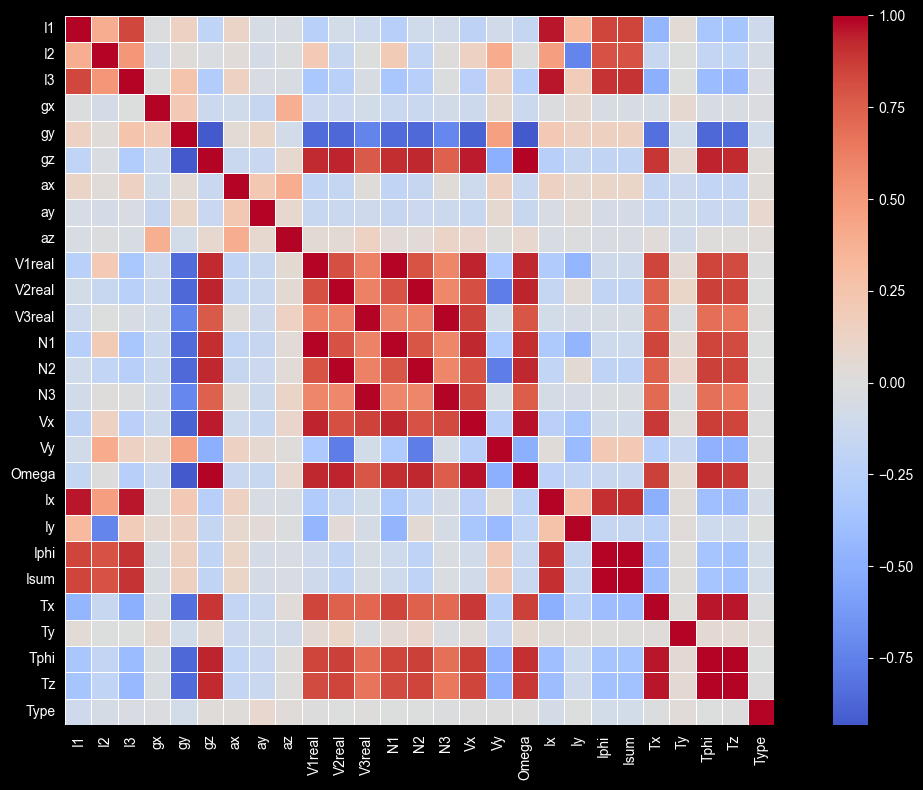

In [34]:
# Построение тепловой карты
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include=['number']).corr(),
            annot=False,  # показывать значения
            cmap='coolwarm',  # цветовая схема
            center=0,  # центр цветовой шкалы
            fmt='.2f',  # формат чисел
            square=True,  # квадратные ячейки
            linewidths=0.5)  # линии между ячейками

plt.tight_layout()
plt.show()

In [ ]:
# Выбираем только числовые колонки
numeric_columns = df.select_dtypes(include=['number']).columns

# Создаем отдельный график для каждой величины
num_plots = len(numeric_columns)
fig, axes = plt.subplots(num_plots, 1, figsize=(12, 5 * num_plots))

if num_plots == 1:
    axes = [axes]

for i, col in enumerate(numeric_columns):
    axes[i].plot(df.index, df[col], marker='o', linestyle='-', markersize=3, linewidth=1)
    axes[i].set_title(f'График величины: {col}', fontsize=14)
    axes[i].grid(True, alpha=0.3)
    axes[i].axhline(y=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()

По графикам видно, что столбцы N1, N2, N3 повторяют w1,w2,w3. Принято решение оставить только скорости, а обороты удалить.

In [ ]:
df = df.drop(['N1', 'N2', 'N3'], axis=1)

Сначала проверяется точность модели на необработанных данных. Данные все равно необходимо подготовить: выборка разбивается в соотношении 80/20, а данные перемешиваются так, чтобы необходимая поверхность встречалась с одинаковой частотой в тренировочной и валидационной выборке.

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('Type', axis=1)  # все признаки
y = df['Type']  # целевая переменная

# Разделение на тренировочную (80%) и тестовую (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,  # для воспроизводимости результатов
    stratify=y  # сохраняет соотношение классов
)

# Проверка соотношения классов
print("Соотношение выходов '0' и '1':")

print("\nВ ТРЕНИРОВОЧНОЙ выборке (80%):")
print(y_train.value_counts(normalize=True))

print("\nВ ТЕСТОВОЙ выборке (20%):")
print(y_test.value_counts(normalize=True))

Можно обучать модель

In [26]:
# Строится модель
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score,f1_score, classification_report, confusion_matrix
import joblib

# Создание и обучение модели MLP
mlp = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42,
    verbose=True
)

In [ ]:
# Только масштабирование
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Обучение модели
mlp.fit(X_train_scaled, y_train)

# Сохраняем модель и scaler для последующей валидации
joblib.dump(mlp, 'mlp_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

In [ ]:
# Кросс-валидация
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# StratifiedKFold сохраняет пропорцию классов в каждом fold'е
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Оценка точности на каждом fold'е
accuracy_scores = cross_val_score(mlp, X_scaled, y, cv=cv, scoring='accuracy')
f1_scores = cross_val_score(mlp, X_scaled, y, cv=cv, scoring='f1')

print(f"\nAccuracy по fold'ам: {accuracy_scores}")
print(f"Средняя Accuracy: {accuracy_scores.mean():.4f} (+/- {accuracy_scores.std():.4f})")

print(f"\nF1-score по fold'ам: {f1_scores}")
print(f"Средний F1-score: {f1_scores.mean():.4f} (+/- {f1_scores.std():.4f})")

# Получение предсказаний для всех данных с помощью кросс-валидации
y_pred_cv = cross_val_predict(mlp, X_scaled, y, cv=cv)

# Общая матрица ошибок
cm = confusion_matrix(y, y_pred_cv)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Class 0', 'Class 1'],
            yticklabels=['Class 0', 'Class 1'])
plt.title('Матрица ошибок (кросс-валидация)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Общий отчет о классификации
print("\nИТОГОВЫЙ ОТЧЕТ О КЛАССИФИКАЦИИ (кросс-валидация):")
print(classification_report(y, y_pred_cv, target_names=['Class 0', 'Class 1']))

# График сравнения реальных и предсказанных значений
plt.figure(figsize=(15, 5))
indices = range(len(y))
plt.plot(indices, y, 'o-', label='Реальный Type', markersize=3, alpha=0.7, linewidth=0.8)
plt.plot(indices, y_pred_cv, 's--', label='Предсказанный Type (CV)', markersize=3, alpha=0.7, linewidth=0.8)
plt.title('Сравнение реальных и предсказанных значений (кросс-валидация)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Предсказания для обеих выборок
y_train_pred = mlp.predict(X_train_scaled)
y_test_pred = mlp.predict(X_test_scaled)

# Метрики
print("РЕЗУЛЬТАТЫ ОБУЧЕНИЯ MLP МОДЕЛИ")

print("\nТРЕНИРОВОЧНАЯ ВЫБОРКА:")
print(f"   Accuracy:  {accuracy_score(y_train, y_train_pred):.4f}")
print(f"   F1-score:  {f1_score(y_train, y_train_pred):.4f}")

print("\nТЕСТОВАЯ ВЫБОРКА:")
print(f"   Accuracy:  {accuracy_score(y_test, y_test_pred):.4f}")
print(f"   F1-score:  {f1_score(y_test, y_test_pred):.4f}")

# Матрица ошибок
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Class 0', 'Class 1'],
            yticklabels=['Class 0', 'Class 1'])
plt.title('Матрица ошибок (тестовая выборка)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# График сравнения
plt.figure(figsize=(15, 5))
indices = range(len(y_test))

plt.plot(indices, y_test, 'o-', label='Реальный Type',
         markersize=4, alpha=0.7, linewidth=1)
plt.plot(indices, y_test_pred, 's--', label='Предсказанный Type',
         markersize=4, alpha=0.7, linewidth=1)

plt.title('Сравнение реальных и предсказанных значений\n( {} строк)'.format(len(y_test)), fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()